<a href="https://colab.research.google.com/github/caroline-2204/AIWIDS_TEAM-21/blob/feature-engineering/ai-wids-complete/notebooks/WebsiteSpoofing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
try:
  from google.colab import drive
  drive.mount('/content/drive')
  os.chdir("/content/drive/MyDrive/COMP530-Project")
except ImportError:
  os.chdir("../data/processed")

Mounted at /content/drive


In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
import pandas as pd
df = pd.read_csv(
    "AWID3_Parsed/Website_spoofing.csv",
    escapechar='\\',
    low_memory=False,
    skiprows=range(1, 1400000),
    nrows=500000
    )

In [ ]:
desc_df = df.describe().T
filtered_df = desc_df[
    (desc_df['count'] >= 300000.0) &
    (desc_df['std'] > 0)
     ]
sorted_df = filtered_df.sort_values(by='std')
display(sorted_df)

,count,mean,std,min,25%,50%,75%,max
frame.time_delta_displayed,500000.0,1.240202e-04,8.601849e-04,0.000000e+00,3.000000e-06,4.600000e-05,1.200000e-04,1.024250e-01
frame.time_delta,500000.0,1.240202e-04,8.601849e-04,0.000000e+00,3.000000e-06,4.600000e-05,1.200000e-04,1.024250e-01
wlan.fc.type,500000.0,1.409332e+00,4.941981e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
wlan_radio.phy,500000.0,6.224570e+00,1.474481e+00,5.000000e+00,5.000000e+00,5.000000e+00,8.000000e+00,8.000000e+00
wlan.fc.subtype,500000.0,9.584186e+00,1.706459e+00,0.000000e+00,8.000000e+00,9.000000e+00,1.100000e+01,1.400000e+01
radiotap.length,500000.0,5.922077e+01,3.923761e+00,4.800000e+01,5.600000e+01,5.600000e+01,6.400000e+01,6.400000e+01
wlan_radio.signal_dbm,500000.0,-4.842743e+01,1.433935e+01,-8.400000e+01,-6.000000e+01,-5.400000e+01,-3.400000e+01,-2.900000e+01
frame.time_relative,500000.0,5.024564e+02,1.804311e+01,4.708444e+02,4.876605e+02,5.021009e+02,5.184616e+02,5.328544e+02
frame.time_epoch,500000.0,1.608061e+09,1.804311e+01,1.608061e+09,1.608061e+09,1.608061e+09,1.608061e+09,1.608061e+09
wlan_radio.data_rate,500000.0,7.055648e+01,6.178097e+01,6.000000e+00,2.400000e+01,2.400000e+01,1.444444e+02,1.733333e+02


In [ ]:
if 'ip.addr' in df.columns:
    display(df['ip.addr'].value_counts())
else:
    print("'ip.addr' column not found in the DataFrame.")

'ip.addr' column not found in the DataFrame.


In [ ]:
import numpy as np

condition = (
    ((df['wlan.sa'] == '04:ed:33:e0:24:82') | (df['wlan.da'] == '04:ed:33:e0:24:82')) |
    ((df['wlan.sa'] == '00:C0:CA:A8:29:56') | (df['wlan.da'] == '00:C0:CA:A8:29:56')) |
    ((df['wlan.sa'] == '24:F5:A2:EA:86:C3') | (df['wlan.da'] == '24:F5:A2:EA:86:C3')) |
    ((df['wlan.sa'] == '00:C0:CA:A8:26:3E') | (df['wlan.da'] == '00:C0:CA:A8:26:3E'))
) & (df['frame.number'] >= 16410) & (df['frame.number'] <= 2668583)

df['label'] = np.where(condition, 'website_spoofing', 'normal')

# Display the count of each label to verify
display(df['label'].value_counts())

,count
label,
normal,368024
website_spoofing,131976


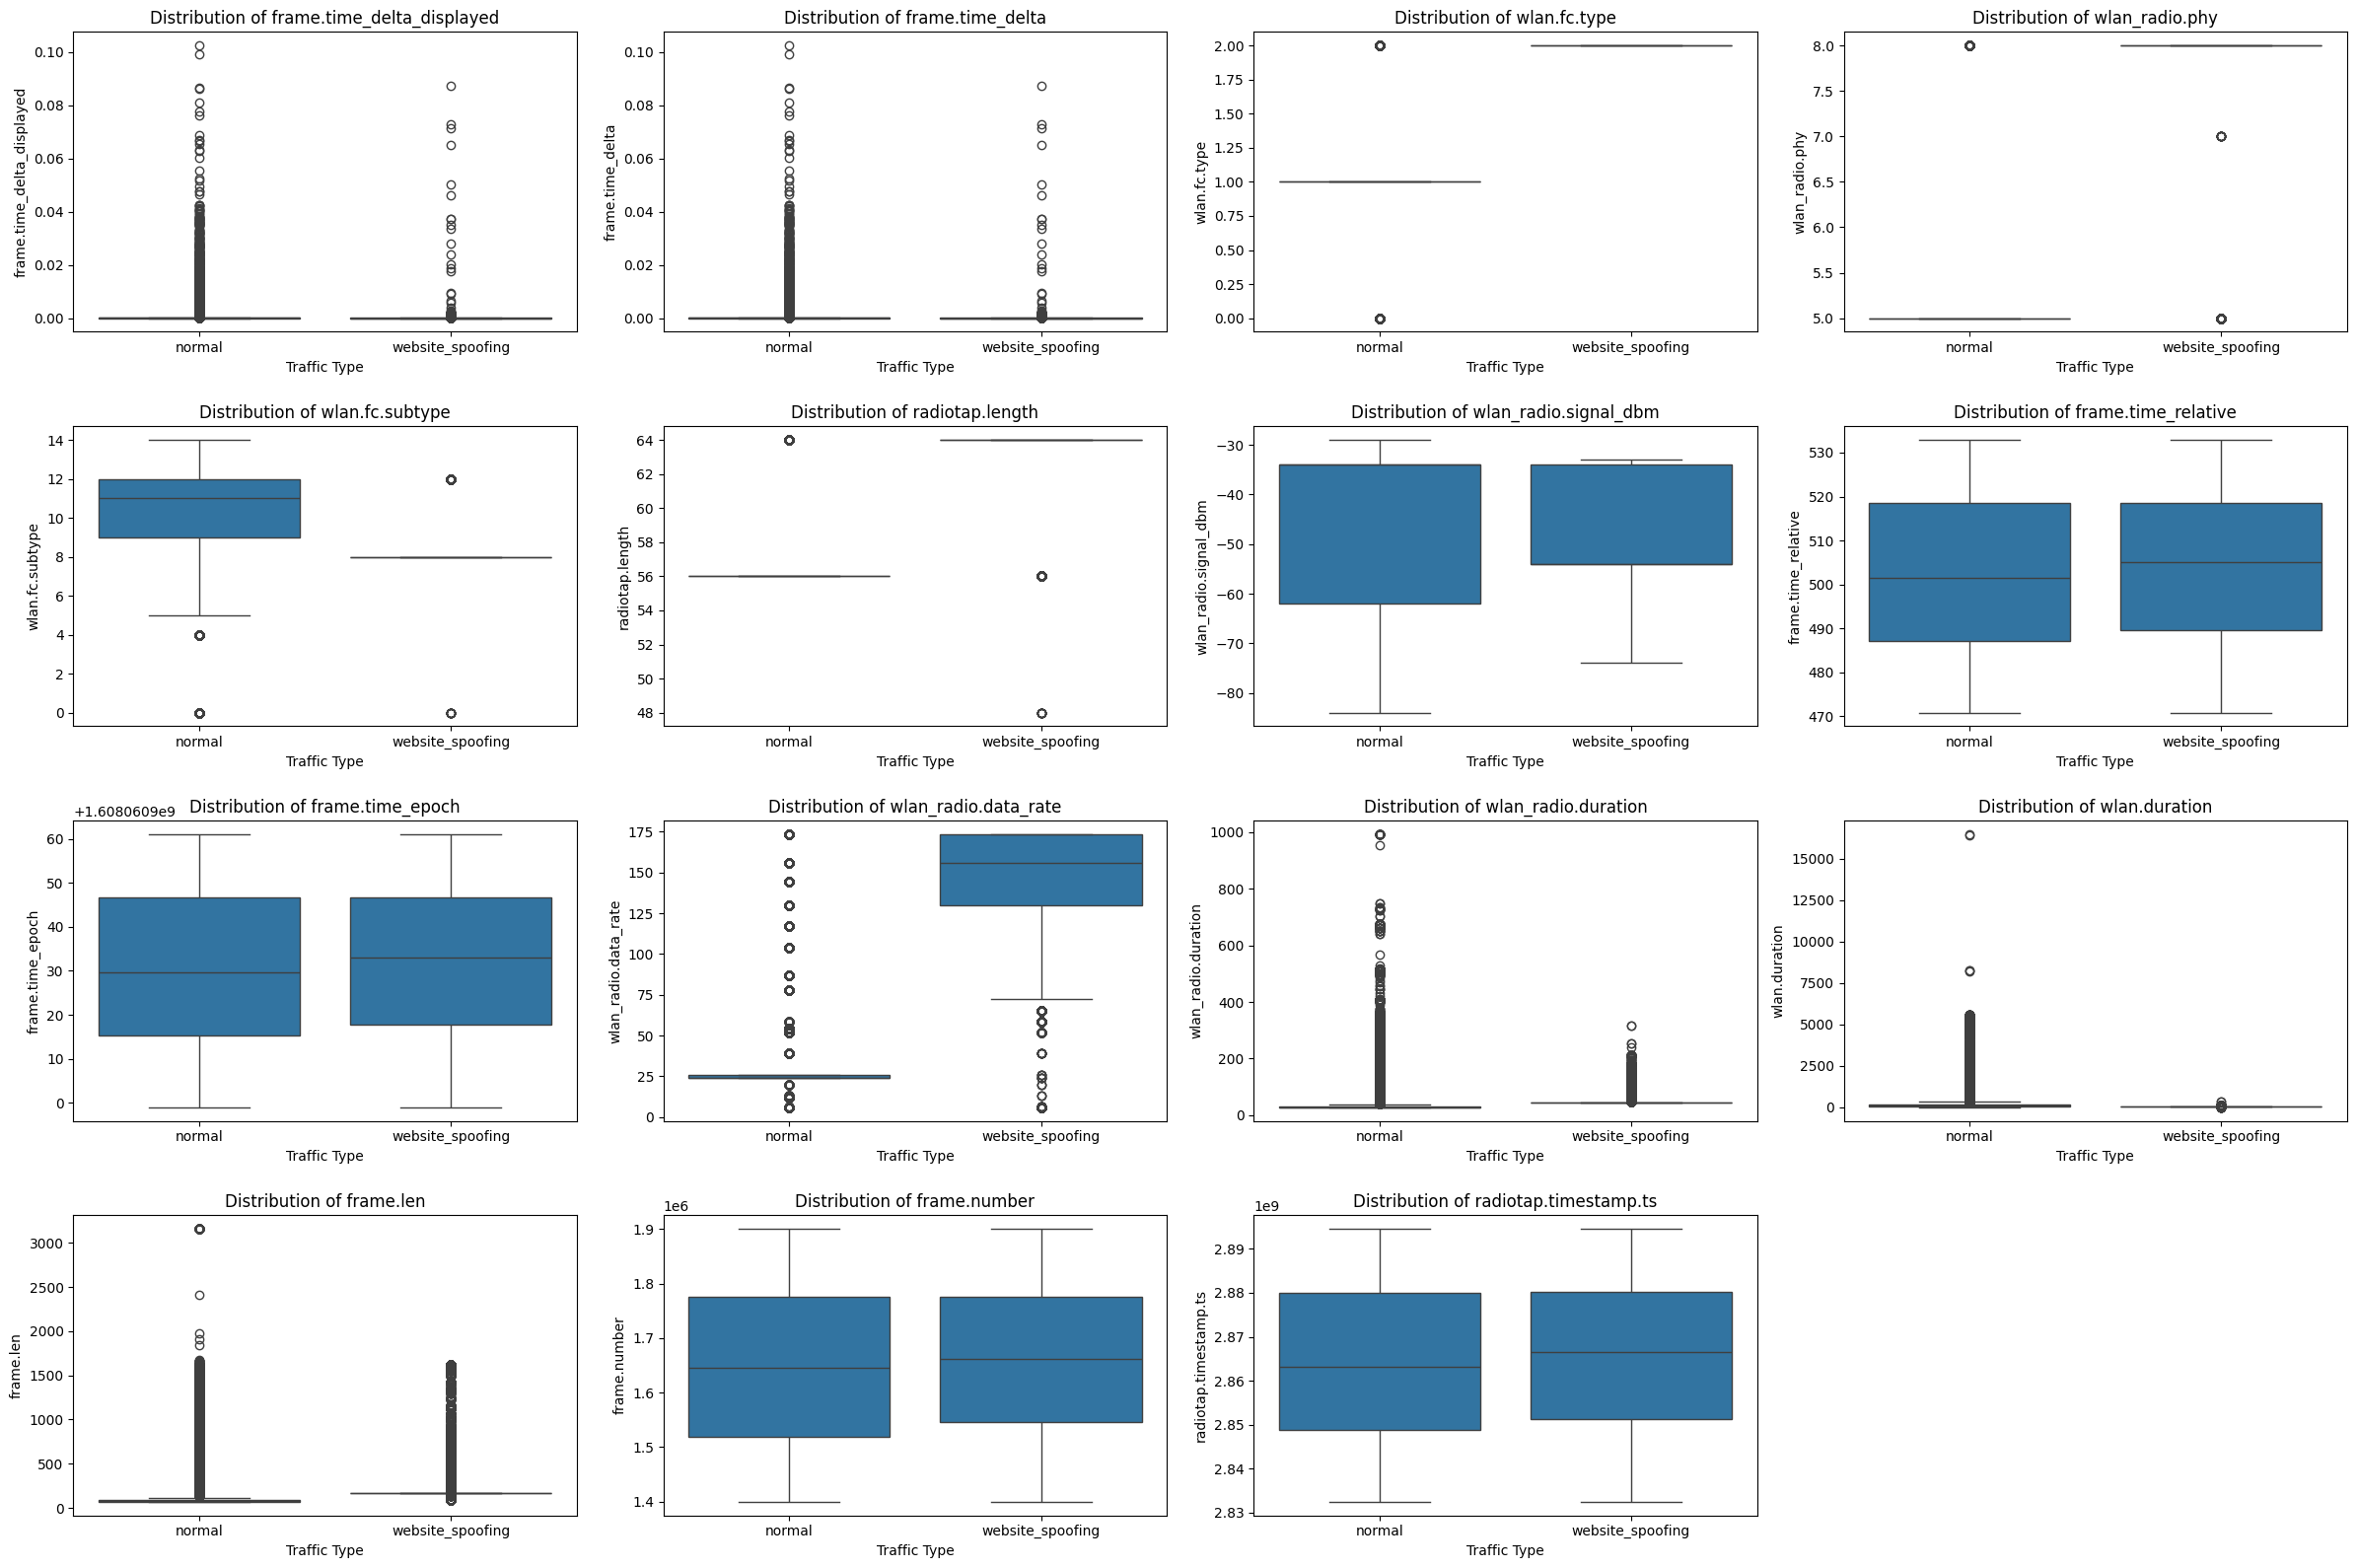

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of columns to plot from the index of sorted_df
columns_to_plot = sorted_df.index.tolist()

# Determine grid dimensions for subplots
num_columns = len(columns_to_plot)
num_cols_grid = 4  # Adjust as needed
num_rows_grid = (num_columns + num_cols_grid - 1) // num_cols_grid

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(num_cols_grid * 6, num_rows_grid * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(columns_to_plot):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Traffic Type')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()